# Chapter 1. PennyLane 시작하기

**Quantum AI: 핸즈온 양자머신러닝 with PennyLane — Part 1**

## 학습 목표
- PennyLane 설치와 import 확인하기
- 첫 번째 양자 회로(QNode)를 정의하고 실행하기
- 상태 벡터, 확률, 기댓값 측정의 차이 직접 확인하기
- 회로를 시각화하는 두 가지 방법(텍스트, 그림) 익히기

## 1.1 환경 준비
PennyLane은 `pip install pennylane`으로 설치할 수 있다. 본 튜토리얼에서는 시뮬레이터 `default.qubit`만 사용하므로 추가 플러그인은 필요 없다.

In [2]:
%pip install -q pennylane

Note: you may need to restart the kernel to use updated packages.


In [12]:
import pennylane as qml
from pennylane import numpy as pnp  # 자동미분 가능한 NumPy
import numpy as np
import matplotlib.pyplot as plt

# 버전 확인
print(f'PennyLane version: {qml.__version__}')
print(f'NumPy version: {np.__version__}')

PennyLane version: 0.42.3
NumPy version: 2.2.6


## 1.2 디바이스 만들기
디바이스는 양자 회로가 실행되는 백엔드다. 여기서는 1큐비트짜리 기본 시뮬레이터를 만든다.

In [13]:
# 1큐비트 시뮬레이터 생성
dev = qml.device('default.qubit', wires=1)
print(dev)

<default.qubit device (wires=1) at 0x1329c5510>


## 1.3 첫 번째 양자 회로 (QNode)
함수에 `@qml.qnode(dev)` 데코레이터를 붙이면 양자 회로가 된다. Hadamard 게이트는 `|0⟩`을 균등 중첩 상태 `(|0⟩+|1⟩)/√2`로 만든다.

In [14]:
@qml.qnode(dev)
def first_circuit():
    # 0번 큐비트에 Hadamard 게이트를 적용
    qml.Hadamard(wires=0)
    # 측정: |0⟩과 |1⟩이 나올 확률을 반환
    return qml.probs(wires=0)

probs = first_circuit()
print(f'P(|0>) = {probs[0]:.4f},  P(|1>) = {probs[1]:.4f}')

P(|0>) = 0.5000,  P(|1>) = 0.5000


Hadamard 게이트 한 번으로 양쪽 확률이 정확히 0.5가 된다. 이것이 양자 중첩(superposition)이다.

## 1.4 같은 회로를 세 가지 방식으로 측정하기
측정 방식에 따라 반환값의 형태가 다르다.

In [15]:
# (a) 확률 분포
@qml.qnode(dev)
def circuit_probs():
    qml.Hadamard(wires=0)
    return qml.probs(wires=0)

# (b) Pauli-Z의 기댓값 — ML에서 손실 함수로 가장 자주 쓰임
@qml.qnode(dev)
def circuit_expval():
    qml.Hadamard(wires=0)
    return qml.expval(qml.PauliZ(0))

# (c) 상태 벡터 — 디버깅용
@qml.qnode(dev)
def circuit_state():
    qml.Hadamard(wires=0)
    return qml.state()

print('확률    :', circuit_probs())
print('⟨Z⟩    :', circuit_expval())
print('상태벡터:', circuit_state())

확률    : [0.5 0.5]
⟨Z⟩    : 0.0
상태벡터: [0.70710678+0.j 0.70710678+0.j]


**해석.** Hadamard 적용 후의 상태는 `(|0⟩ + |1⟩)/√2`이므로 두 진폭은 `1/√2 ≈ 0.7071`로 같다. Pauli-Z의 기댓값은 `P(|0⟩) - P(|1⟩) = 0`이 된다.

## 1.5 회로 시각화
PennyLane은 회로를 두 가지 방법으로 시각화한다.

In [16]:
# 텍스트 다이어그램
print(qml.draw(circuit_probs)())

0: ──H─┤  Probs


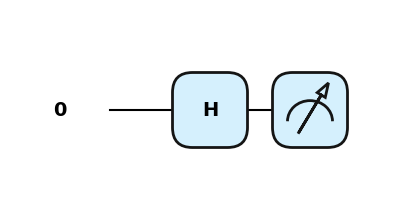

In [17]:
# 그림 다이어그램
fig, ax = qml.draw_mpl(circuit_probs, style="pennylane")()
plt.show()

## 1.6 여러 큐비트와 얽힘 만들기
2큐비트 Bell 회로는 Hadamard + CNOT로 만든다.

In [18]:
dev2 = qml.device('default.qubit', wires=2)

@qml.qnode(dev2)
def bell_circuit():
    # 큐비트 0에 Hadamard → 균등 중첩
    qml.Hadamard(wires=0)
    # 큐비트 0이 |1>일 때 큐비트 1을 뒤집음 → 얽힘 생성
    qml.CNOT(wires=[0, 1])
    return qml.probs(wires=[0, 1])

probs = bell_circuit()
labels = ['|00>', '|01>', '|10>', '|11>']
for label, p in zip(labels, probs):
    print(f'{label}: {p:.4f}')

|00>: 0.5000
|01>: 0.0000
|10>: 0.0000
|11>: 0.5000


Bell 상태 `|Φ+⟩ = (|00⟩ + |11⟩)/√2`에서는 `|00⟩`과 `|11⟩`만 각각 0.5의 확률로 나타난다. 두 큐비트의 측정 결과가 완전히 상관되어 있다는 뜻이다.

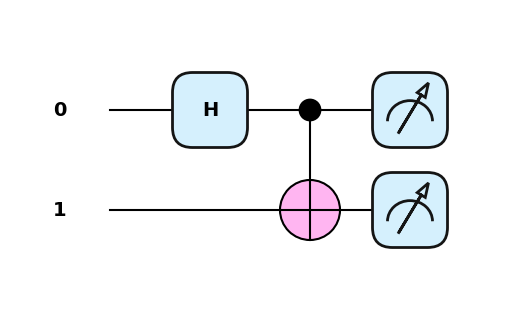

In [20]:
# Bell 회로 시각화
fig, ax = qml.draw_mpl(bell_circuit, style="pennylane")()
plt.show()

## 1.7 정리
- `qml.device`로 백엔드를 만들고 `@qml.qnode(dev)`로 회로를 정의한다.
- 측정 종류: `qml.probs`, `qml.expval`, `qml.state`, `qml.sample`
- 회로 시각화: `qml.draw` (텍스트), `qml.draw_mpl` (그림)
- Hadamard로 중첩, CNOT으로 얽힘을 만든다.

다음 장에서는 큐비트와 양자 게이트의 수학적 구조를 더 깊이 다룬다.